In [13]:
from e3nn import o3
import torch

In [14]:
o3.Irreps("1x0ee + 1x2oe").randn(-1, 1)

tensor([[-0.8840],
        [-0.9054],
        [ 0.4417],
        [ 0.7673],
        [ 0.0092],
        [-0.8059]])

In [18]:
irreps_sh = o3.Irreps.spherical_harmonics(lmax = 2)
print(irreps_sh)

edge_vec = torch.randn(10, 3)

sh = o3.spherical_harmonics(irreps_sh, edge_vec, normalize=True, normalization='component')
# normalize=True ensure that x is divided by |x| before computing the sh

sh.pow(2).mean()  # should be close to 1

1x0ee+1x1oe+1x2ee


tensor(1.)

In [27]:
irreps_input = o3.Irreps("1x0ee + 1x1oe + 1x2ee + 1x0eo + 1x1oo + 1x2eo + 1x0oe + 1x1ee + 1x2oe + 1x0oo + 1x1eo + 1x2oo")
irreps_output = o3.Irreps("1x0ee + 1x0oe + 1x0oo + 1x0eo")

In [28]:
f_in = irreps_input.randn(len(edge_vec), -1)

FullyConnectedTensorProduct(1x0ee+1x1oe+1x2ee+1x0eo+1x1oo+1x2eo+1x0oe+1x1ee+1x2oe+1x0oo+1x1eo+1x2oo x 1x0ee+1x1oe+1x2ee -> 1x0ee+1x0oe+1x0oo+1x0eo | 12 paths | 12 weights) needs 12 weights


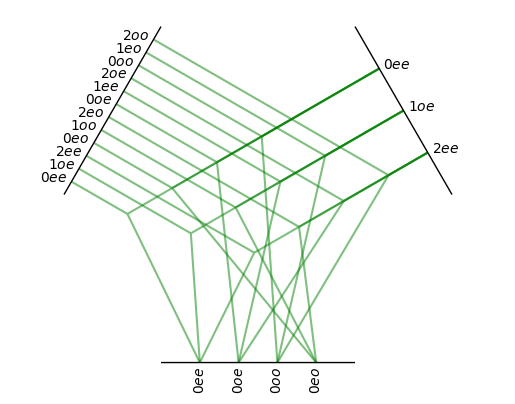

In [29]:
tp = o3.FullyConnectedTensorProduct(irreps_input, irreps_sh, irreps_output, shared_weights=False)

print(f"{tp} needs {tp.weight_numel} weights")

tp.visualize();